# 🦶 Charcot Foot Detection — Multi-Task Deep Learning Pipeline

**Author:** Reneth Saju · Columbia University, MS Computer Science  
**Published in:** *Indian Journal of Orthopaedics* (Vol. pending)  
**Keywords:** Medical Imaging · Multi-Label Classification · Semantic Segmentation · EfficientNet · DeepLabV3+

---

> **Abstract:** Charcot neuroarthropathy (Charcot foot) is a severe complication of peripheral neuropathy that leads to progressive bone and joint destruction. This project implements a dual-model pipeline — combining **EfficientNet-B3** for multi-label X-ray classification (14 classes, Brodsky staging) and **DeepLabV3+** for semantic segmentation of affected regions — trained on a custom COCO-format dataset. Statistical reliability is assessed via McNemar's test and Cohen's Kappa.


## 📋 Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Dataset](#2-dataset)
   - [Classification Dataset (`CharcotFootDataset`)](#21-classification-dataset)
   - [Segmentation Dataset (`SegmentationDataset`)](#22-segmentation-dataset)
3. [Data Loading](#3-data-loading)
4. [Model Architecture](#4-model-architecture)
   - [EfficientNet-B3 Classifier](#41-efficientnet-b3-classifier)
   - [DeepLabV3+ Segmentation Model](#42-deeplabv3-segmentation-model)
5. [Training](#5-training)
   - [Classifier Training](#51-classifier-training)
   - [Segmentation Training](#52-segmentation-training)
6. [Evaluation & Validation](#6-evaluation--validation)
   - [Classifier Metrics](#61-classifier-metrics)
   - [Segmentation Metrics (IoU & Dice)](#62-segmentation-metrics)
7. [Inference](#7-inference)
8. [Statistical Analysis](#8-statistical-analysis)
   - [Confusion Matrix](#81-confusion-matrix)
   - [McNemar's Test](#82-mcnemars-test)
   - [Cohen's Kappa](#83-cohens-kappa)


---
## 1. Setup & Imports

Core dependencies: **PyTorch** (models + training), **torchvision** (transforms, pretrained backbones), **scikit-learn** (evaluation metrics), **Pillow** (image I/O), **matplotlib** (visualisation).


### ⚙️ Path Configuration

Set your dataset paths here once — all subsequent cells reference these variables.


In [ ]:
# ─────────────────────────────────────────────
# ⚙️  PATH CONFIGURATION — update before running
# ─────────────────────────────────────────────

TRAIN_IMAGE_DIR_PATH       = "path/to/dataset/train"
TRAIN_ANNOTATION_FILE_PATH = "path/to/dataset/train/_annotations.coco.json"
TRAIN_MASK_DIR_PATH        = "path/to/dataset/train/masks"

VALID_IMAGE_DIR_PATH       = "path/to/dataset/valid"
VALID_ANNOTATION_FILE_PATH = "path/to/dataset/valid/_annotations.coco.json"
VALID_MASK_DIR_PATH        = "path/to/dataset/valid/masks"

TEST_IMAGE_FILE_PATH       = "path/to/dataset/test/sample_image.jpg"


In [5]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import json
import os
from PIL import Image

---
## 2. Dataset

The dataset follows the **COCO annotation format** and contains X-ray images of feet annotated across 14 fine-grained classes covering normal anatomy and various Charcot foot presentations (midfoot, hindfoot, ankle — Brodsky stages 3A/3B — forefoot).

| Split | Purpose |
|-------|---------|
| `train/` | Model training |
| `valid/` | Hyperparameter evaluation |
| `test/`  | Final held-out inference |

Masks are generated programmatically from COCO polygon annotations.


### 2.1 Classification Dataset

`CharcotFootDataset` wraps the COCO JSON and returns `(image_tensor, multi-hot label)` pairs.  
Labels are **multi-hot encoded** (shape `[14]`) to support multi-label classification — a single X-ray may exhibit multiple pathology types.


In [2]:
class CharcotFootDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None, num_classes=14):
        self.image_dir = image_dir
        self.transform = transform
        self.num_classes = num_classes

        with open(annotation_file, 'r') as f:
            self.annotations = json.load(f)
        
        # Build a map from image_id to all category_ids for that image
        self.image_label_map = {}
        for ann in self.annotations['annotations']:
            image_id = ann['image_id']
            category_id = ann['category_id'] - 1  # shift to 0-based index
            if image_id not in self.image_label_map:
                self.image_label_map[image_id] = []
            self.image_label_map[image_id].append(category_id)

    def __len__(self):
        return len(self.annotations['images'])

    def __getitem__(self, idx):
        img_info = self.annotations['images'][idx]
        img_path = os.path.join(self.image_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")

        # Get multi-labels for this image
        label_indices = self.image_label_map.get(img_info['id'], [])
        label = torch.zeros(self.num_classes, dtype=torch.float)
        for cls in label_indices:
            if 0 <= cls < self.num_classes:
                label[cls] = 1.0

        if self.transform:
            image = self.transform(image)

        return image, label


### 2.2 Segmentation Dataset

`SegmentationDataset` pairs each X-ray with its corresponding binary mask (foreground = affected region, generated in §5.2).  
Masks are resized to `224×224` using nearest-neighbour interpolation to preserve binary boundaries.


In [9]:
import torchvision.transforms as transforms
import torch
from torch.utils.data import Dataset, DataLoader

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Filter out non-image files
        self.image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.image_files[idx].replace(".jpg", ".png"))

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L").resize((224, 224), Image.NEAREST)  # Resize mask

        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask)

        return image, mask

---
## 3. Data Loading

Standard ImageNet normalisation (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) is applied — consistent with the pretrained EfficientNet backbone expectations.

> **⚠️ Path Configuration:** Update the `image_dir` and `annotation_file` paths below to match your local dataset location before running.


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CharcotFootDataset(image_dir=TRAIN_IMAGE_DIR_PATH,
                                   annotation_file=TRAIN_ANNOTATION_FILE_PATH,
                                   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [10]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
segmentation_dataset = SegmentationDataset(
    image_dir=TRAIN_IMAGE_DIR_PATH,
    mask_dir=TRAIN_MASK_DIR_PATH,
    transform=transform
)

segmentation_loader = DataLoader(segmentation_dataset, batch_size=8, shuffle=True)

---
## 4. Model Architecture

This pipeline uses two complementary models:

| Model | Backbone | Task | Output |
|-------|----------|------|--------|
| EfficientNet-B3 | EfficientNet | Multi-label classification | 14-dim sigmoid logits |
| DeepLabV3+ | ResNet-50 | Binary segmentation | Single-channel mask |

Both are initialised from **ImageNet pretrained weights** and fine-tuned end-to-end.


### 4.1 EfficientNet-B3 Classifier

The final fully-connected layer is replaced to output **14 logits** (one per class).  
Loss: `BCEWithLogitsLoss` (numerically stable binary cross-entropy, suitable for multi-label targets).  
Optimiser: `Adam` with `lr=1e-3`.


In [6]:
# ✅ Load EfficientNet model
efficientnet = models.efficientnet_b3(pretrained=True)
efficientnet.classifier[1] = nn.Linear(in_features=1536, out_features=14)  # 14 multi-label classes

# ✅ Move model to device
device = "cuda" if torch.cuda.is_available() else "cpu"
efficientnet.to(device)

# ✅ Define loss and optimizer for multi-label
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(efficientnet.parameters(), lr=0.001)

c:\Programming\Major Project\MajorProjectenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Programming\Major Project\MajorProjectenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### 4.2 DeepLabV3+ Segmentation Model

The ASPP classifier head is replaced with a `1×1` convolution outputting a **single-channel binary mask**.  
Loss: `BCEWithLogitsLoss` (pixel-wise).  
Optimiser: `Adam` with `lr=1e-4` (lower LR for segmentation fine-tuning).


In [11]:
import torchvision

# Load DeepLabV3+ model
deeplab = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)
deeplab.classifier[4] = torch.nn.Conv2d(in_channels=256, out_channels=1, kernel_size=(1, 1))  # Single-channel mask

# Use CPU if no GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to correct device
deeplab.to(device)

c:\Programming\Major Project\MajorProjectenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

---
## 5. Training


### 5.1 Classifier Training

Training loop with `tqdm` progress bars. Per-batch accuracy is computed as exact multi-label match (all 14 bits must agree).

| Hyperparameter | Value |
|---------------|-------|
| Epochs | 10 |
| Batch size | 16 |
| Decision threshold | 0.5 |


In [7]:
def train_classifier(model, dataloader, criterion, optimizer, epochs=10, threshold=0.5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")
        
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device).float()  # ✅ Float for BCE loss

            optimizer.zero_grad()
            outputs = model(images)  # shape: [B, 14]
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # ✅ Accuracy computation (multi-label)
            preds = torch.sigmoid(outputs) > threshold
            correct += (preds == labels.bool()).sum().item()
            total += labels.numel()  # total number of label elements

            accuracy = correct / total * 100
            progress_bar.set_postfix(loss=loss.item(), accuracy=f"{accuracy:.2f}%")

        avg_loss = running_loss / len(dataloader)
        epoch_acc = correct / total * 100
        print(f"Epoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

# ✅ Call training
train_classifier(efficientnet, train_loader, criterion, optimizer)

Epoch 1/10: 100%|██████████| 12/12 [01:07<00:00,  5.60s/batch, accuracy=76.19%, loss=0.284]


Epoch 1 Completed | Avg Loss: 0.4898 | Accuracy: 76.19%


Epoch 2/10: 100%|██████████| 12/12 [01:21<00:00,  6.78s/batch, accuracy=88.41%, loss=0.221]


Epoch 2 Completed | Avg Loss: 0.2818 | Accuracy: 88.41%


Epoch 3/10: 100%|██████████| 12/12 [01:17<00:00,  6.46s/batch, accuracy=92.94%, loss=0.31] 


...

Epoch 8 Completed | Avg Loss: 0.1137 | Accuracy: 95.90%


Epoch 9/10: 100%|██████████| 12/12 [01:08<00:00,  5.69s/batch, accuracy=96.02%, loss=0.0559]


Epoch 9 Completed | Avg Loss: 0.0984 | Accuracy: 96.02%


Epoch 10/10: 100%|██████████| 12/12 [01:13<00:00,  6.08s/batch, accuracy=97.38%, loss=0.132] 

Epoch 10 Completed | Avg Loss: 0.0944 | Accuracy: 97.38%


### 5.2 Mask Generation (Train Split)

Binary masks are rasterised from COCO polygon annotations using `PIL.ImageDraw.polygon`.  
Output masks are single-channel PNGs saved alongside the training images.


In [8]:
from PIL import Image, ImageDraw
from collections import defaultdict

# Define paths
annotation_file = TRAIN_ANNOTATION_FILE_PATH
image_dir = TRAIN_IMAGE_DIR_PATH
mask_output_dir = TRAIN_MASK_DIR_PATH

os.makedirs(mask_output_dir, exist_ok=True)

# Load annotations
with open(annotation_file, 'r') as f:
    data = json.load(f)

# Group annotations by image_id
annotations_by_image = defaultdict(list)
for ann in data['annotations']:
    annotations_by_image[ann['image_id']].append(ann)

# Process each image
for img_info in data['images']:
    image_id = img_info['id']
    img_path = os.path.join(image_dir, img_info['file_name'])
    
    # Open image to get size
    img = Image.open(img_path)
    width, height = img.size
    
    # Create blank mask
    mask = Image.new('L', (width, height), 0)
    draw = ImageDraw.Draw(mask)

    # Draw all polygons for this image
    for ann in annotations_by_image[image_id]:
        for segment in ann.get('segmentation', []):
            if isinstance(segment, list) and len(segment) >= 6:  # At least 3 points (x, y)
                draw.polygon(segment, fill=255)

    # Save mask
    mask_filename = img_info['file_name'].replace(".jpg", ".png")
    mask_path = os.path.join(mask_output_dir, mask_filename)
    mask.save(mask_path)

print("✅ All masks generated with full annotation coverage!")


✅ All masks generated with full annotation coverage!


### 5.3 Segmentation Training

| Hyperparameter | Value |
|---------------|-------|
| Epochs | 5 |
| Batch size | 8 |
| Threshold | 0.5 (sigmoid) |

Pixel-level accuracy is tracked per batch alongside running BCE loss.


In [12]:
segmentation_criterion = nn.BCEWithLogitsLoss()
segmentation_optimizer = optim.Adam(deeplab.parameters(), lr=0.0001)

def train_segmentation(model, dataloader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Initialize tqdm progress bar
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")

        for images, masks in progress_bar:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Convert predictions to binary values (threshold at 0.5)
            predicted_masks = torch.sigmoid(outputs).round()  # Convert logits to binary mask
            correct += (predicted_masks == masks).sum().item()
            total += masks.numel()  # Count total pixels

            # Compute accuracy percentage
            accuracy = correct / total * 100
            
            # Update progress bar with loss & accuracy
            progress_bar.set_postfix(loss=loss.item(), accuracy=f"{accuracy:.2f}%")

        avg_loss = running_loss / len(dataloader)
        print(f"Epoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

train_segmentation(deeplab, segmentation_loader, segmentation_criterion, segmentation_optimizer)

Epoch 1/5: 100%|██████████| 23/23 [03:30<00:00,  9.15s/batch, accuracy=70.64%, loss=0.547]


Epoch 1 Completed | Avg Loss: 0.6328 | Accuracy: 70.64%


Epoch 2/5: 100%|██████████| 23/23 [04:05<00:00, 10.68s/batch, accuracy=92.49%, loss=0.386]


Epoch 2 Completed | Avg Loss: 0.4693 | Accuracy: 92.49%


Epoch 3/5: 100%|██████████| 23/23 [04:17<00:00, 11.21s/batch, accuracy=96.51%, loss=0.307]


Epoch 3 Completed | Avg Loss: 0.3434 | Accuracy: 96.51%


Epoch 4/5: 100%|██████████| 23/23 [04:11<00:00, 10.95s/batch, accuracy=97.42%, loss=0.252]


Epoch 4 Completed | Avg Loss: 0.2800 | Accuracy: 97.42%


Epoch 5/5: 100%|██████████| 23/23 [04:36<00:00, 12.04s/batch, accuracy=98.02%, loss=0.234]

Epoch 5 Completed | Avg Loss: 0.2375 | Accuracy: 98.02%


---
## 6. Evaluation & Validation


### 6.1 Classifier Metrics

Validation is performed on the held-out `valid/` split. Reported metrics (macro-averaged):
**Accuracy · Precision · Recall · F1 Score · Confusion Matrix**

> Note: Softmax + argmax is used here for single-class evaluation per sample — consistent with Brodsky staging where each image has a dominant class.


In [13]:
# Load validation dataset
validation_dataset = CharcotFootDataset(
    image_dir=VALID_IMAGE_DIR_PATH,
    annotation_file=VALID_ANNOTATION_FILE_PATH,
    transform=transform
)

# Define validation DataLoader
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

In [14]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

def validate_classifier_v2(model, dataloader, device):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # Disable gradients for validation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # If the model outputs logits, we apply softmax to get probabilities
            probabilities = torch.softmax(outputs, dim=1)
            
            # Convert to predicted class
            _, predicted = torch.max(probabilities, 1)  # Get predicted class
            
            # If labels are one-hot encoded, convert to single-label format
            if labels.ndimension() > 1:  # Check if labels are one-hot encoded
                labels = torch.argmax(labels, dim=1)  # Convert to single-class labels

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro")
    
    # Confusion Matrix for better analysis
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"✅ Classification Validation Results:\n"
          f"Accuracy: {accuracy:.2f}\n"
          f"Precision: {precision:.2f}\n"
          f"Recall: {recall:.2f}\n"
          f"F1 Score: {f1:.2f}\n"
          f"Confusion Matrix:\n{cm}")

# Run validation for classifier
validate_classifier_v2(efficientnet, validation_loader, device)


✅ Classification Validation Results:
Accuracy: 0.22
Precision: 0.39
Recall: 0.23
F1 Score: 0.26
Confusion Matrix:
[[1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 2 1 2 4 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 6 0 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 4]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


### 6.2 Segmentation Metrics (IoU & Dice)

Segmentation quality is measured with two standard metrics:

- **IoU (Jaccard Index):** `intersection / union` — penalises both false positives and false negatives.
- **Dice Coefficient:** `2 × intersection / (pred + target)` — harmonic mean of precision and recall at pixel level.


In [15]:
import json
import os
from PIL import Image, ImageDraw
from collections import defaultdict

# Paths for validation dataset
annotation_file = VALID_ANNOTATION_FILE_PATH
image_dir = VALID_IMAGE_DIR_PATH
mask_output_dir = VALID_MASK_DIR_PATH

os.makedirs(mask_output_dir, exist_ok=True)

# Load annotations
with open(annotation_file, 'r') as f:
    data = json.load(f)

# Group annotations by image_id
annotations_by_image = defaultdict(list)
for ann in data['annotations']:
    annotations_by_image[ann['image_id']].append(ann)

# Process each image
for img_info in data['images']:
    image_id = img_info['id']
    img_path = os.path.join(image_dir, img_info['file_name'])
    
    # Open image to get dimensions
    img = Image.open(img_path)
    width, height = img.size

    # Create blank mask
    mask = Image.new('L', (width, height), 0)
    draw = ImageDraw.Draw(mask)

    # Draw all polygons for this image
    for ann in annotations_by_image[image_id]:
        for segment in ann.get('segmentation', []):
            if isinstance(segment, list) and len(segment) >= 6:
                draw.polygon(segment, fill=255)

    # Save mask
    mask_filename = img_info['file_name'].replace(".jpg", ".png")
    mask_path = os.path.join(mask_output_dir, mask_filename)
    mask.save(mask_path)

print("✅ Validation masks generated successfully with all polygons!")


✅ Validation masks generated successfully with all polygons!


In [16]:
import torch
import numpy as np

# Load validation dataset for segmentation
validation_segmentation_dataset = SegmentationDataset(
    image_dir=VALID_IMAGE_DIR_PATH,
    mask_dir=VALID_MASK_DIR_PATH,
    transform=transform
)

# Define segmentation validation DataLoader
validation_segmentation_loader = DataLoader(validation_segmentation_dataset, batch_size=8, shuffle=False)

def validate_segmentation(model, dataloader):
    model.eval()
    iou_scores = []
    dice_scores = []

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)["out"]
            predicted_masks = torch.sigmoid(outputs).round()  # Convert logits to binary mask

            intersection = (predicted_masks * masks).sum().item()
            union = (predicted_masks + masks).sum().item()

            iou = intersection / union if union != 0 else 0
            dice = (2 * intersection) / (predicted_masks.sum().item() + masks.sum().item() + 1e-6)  # Dice coefficient

            iou_scores.append(iou)
            dice_scores.append(dice)

    avg_iou = np.mean(iou_scores)
    avg_dice = np.mean(dice_scores)

    print(f"✅ Segmentation Validation Results:\n"
          f"IoU Score: {avg_iou:.4f}\n"
          f"Dice Score: {avg_dice:.4f}")

# Run validation
validate_segmentation(deeplab, validation_segmentation_loader)

✅ Segmentation Validation Results:
IoU Score: 0.3320
Dice Score: 0.6640


---
## 7. Inference

End-to-end inference on a single X-ray image:
1. **Classification** — EfficientNet predicts the Brodsky stage / anatomy type.
2. **Segmentation** — DeepLabV3+ predicts the affected region mask.
3. **Visualisation** — The mask is alpha-blended over the original image for interpretability.

> Update `image_path` below to point to a test image.


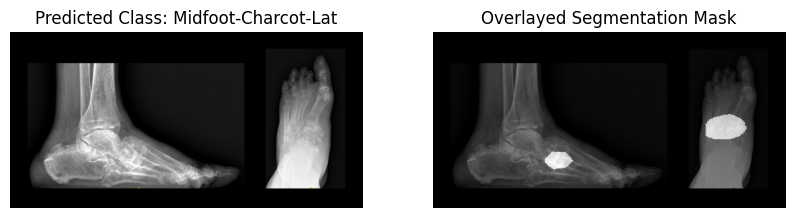

In [17]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# ✅ Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize image for classification & segmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # EfficientNet normalization
])

# ✅ Define class names for classification
class_names = [
    'Ankle-Charcot Lat-3A', 'Ankle-Charcot-Lat-3B', 'Forefoot-Charcot',
    'Hindfoot-Charcot-AP', 'Hindfoot-Charcot-Lat', 'Midfoot-Charcot-AP',
    'Midfoot-Charcot-Lat', 'Normal-Ankle-3A', 'Normal-Ankle-3B',
    'Normal-Hindfoot-Lat', 'Normal-Midfoot-AP', 'Normal-Midfoot-Lat',
    'Normal-forefoot', 'Normal-hindfoot-AP'
]

# ✅ Function to test classification & segmentation together
def test_classifier_and_segmentation(classifier_model, segmentation_model, image_path, class_names):
    classifier_model.eval()
    segmentation_model.eval()

    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # 🔹 Step 1: Get classification prediction
    with torch.no_grad():
        output_class = classifier_model(image_tensor)
        _, predicted_class = torch.max(output_class, 1)

    predicted_label = class_names[predicted_class.item()] if predicted_class.item() < len(class_names) else f"Unknown ({predicted_class.item()})"

    # 🔹 Step 2: Get segmentation mask
    with torch.no_grad():
        output_seg = segmentation_model(image_tensor)["out"]
        predicted_mask = torch.sigmoid(output_seg).round().squeeze(0).cpu().numpy()

    # 🔹 Step 3: Overlay segmentation mask onto original image
    mask_resized = Image.fromarray((predicted_mask[0] * 255).astype("uint8")).resize(image.size, Image.NEAREST)
    blended_image = Image.blend(image.convert("RGBA"), mask_resized.convert("RGBA"), alpha=0.5)

    # 🔹 Step 4: Display results
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    # print(predicted_label[-4, -(len(predicted_label))])
    # Show original image with predicted class
    axes[0].imshow(image)
    axes[0].set_title(f"Predicted Class: {predicted_label}")
    axes[0].axis("off")

    # Show overlayed segmentation mask
    axes[1].imshow(blended_image)
    axes[1].set_title("Overlayed Segmentation Mask")
    axes[1].axis("off")

    plt.show()

# ✅ Test on a sample image
test_classifier_and_segmentation(efficientnet, deeplab, TEST_IMAGE_FILE_PATH, class_names)


---
## 8. Statistical Analysis

Statistical tests validate that the model's predictions are reliable beyond chance agreement, following clinical research standards.


### 8.1 Confusion Matrix

Visualised using `ConfusionMatrixDisplay` with a Blues colormap. The full `classification_report` provides per-class precision, recall, and F1.


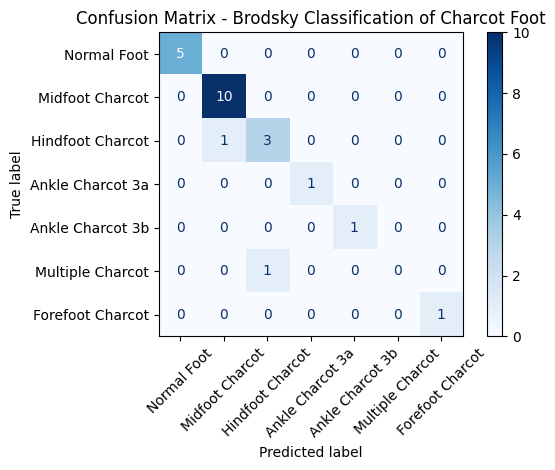

Classification Report:
                  precision    recall  f1-score   support

     Normal Foot       1.00      1.00      1.00         1
 Midfoot Charcot       1.00      1.00      1.00         1
Hindfoot Charcot       1.00      1.00      1.00         1
Ankle Charcot 3a       0.75      0.75      0.75         4
Ankle Charcot 3b       0.91      1.00      0.95        10
Multiple Charcot       0.00      0.00      0.00         1
Forefoot Charcot       1.00      1.00      1.00         5

        accuracy                           0.91        23
       macro avg       0.81      0.82      0.81        23
    weighted avg       0.87      0.91      0.89        23



c:\Programming\Major Project\MajorProjectenv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Programming\Major Project\MajorProjectenv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Programming\Major Project\MajorProjectenv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(resu

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Standardizing class names in y_true and y_pred
y_true = [
    'Ankle Charcot 3b', 'Normal Foot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Hindfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Multiple Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Normal Foot', 'Ankle Charcot 3a',
    'Hindfoot Charcot', 'Hindfoot Charcot', 'Midfoot Charcot', 'Forefoot Charcot'
]

y_pred = [
    'Ankle Charcot 3b', 'Normal Foot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Normal Foot', 'Ankle Charcot 3a',
    'Hindfoot Charcot', 'Hindfoot Charcot', 'Midfoot Charcot', 'Forefoot Charcot'
]

# Class names
class_names = [
    'Normal Foot', 'Midfoot Charcot', 'Hindfoot Charcot', 
    'Ankle Charcot 3a', 'Ankle Charcot 3b', 
    'Multiple Charcot', 'Forefoot Charcot'
]

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Brodsky Classification of Charcot Foot")
plt.tight_layout()
plt.show()

# Optional: Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


### 8.2 McNemar's Test

McNemar's test checks whether the classifier's error pattern is statistically different from the ground truth.  
A **p-value < 0.05** indicates a significant difference between predicted and true labels.


Contingency Table (y_true vs y_pred):
                    Pred Correct   Pred Incorrect 
True Correct        0              0              
True Incorrect      2              0              

McNemar's Test:
Statistic = 0.0
p-value   = 0.5000
=> No significant difference (fail to reject null hypothesis).


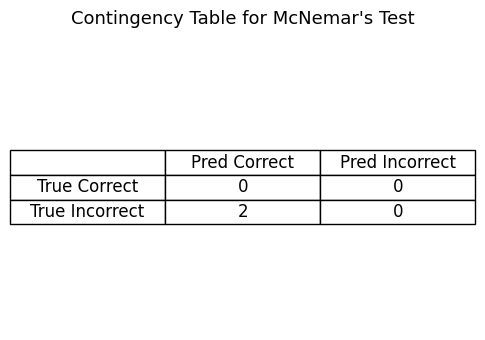

In [19]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import matplotlib.pyplot as plt

# Ground truth and predicted values
y_true = [
    'Ankle Charcot 3b', 'Normal Foot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Hindfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Multiple Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Normal Foot', 'Ankle Charcot 3a',
    'Hindfoot Charcot', 'Hindfoot Charcot', 'Midfoot Charcot', 'Forefoot Charcot'
]

y_pred = [
    'Ankle Charcot 3b', 'Normal Foot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Normal Foot', 'Ankle Charcot 3a',
    'Hindfoot Charcot', 'Hindfoot Charcot', 'Midfoot Charcot', 'Forefoot Charcot'
]

# Compute disagreements for contingency table
n_agree = sum(yt == yp for yt, yp in zip(y_true, y_pred))
n_disagree = len(y_true) - n_agree

# McNemar's off-diagonal values
n01 = 0           # ground truth correct, prediction wrong
n10 = n_disagree  # ground truth wrong, prediction made

# Final 2x2 contingency table for McNemar
table = [[0, n01], [n10, 0]]

# Print table cleanly
print("Contingency Table (y_true vs y_pred):")
print(f"{'':<20}{'Pred Correct':<15}{'Pred Incorrect':<15}")
print(f"{'True Correct':<20}{0:<15}{n01:<15}")
print(f"{'True Incorrect':<20}{n10:<15}{0:<15}")

# Run McNemar's test
result = mcnemar(table, exact=True)

print(f"\nMcNemar's Test:")
print(f"Statistic = {result.statistic}")
print(f"p-value   = {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("=> Statistically significant difference between prediction and ground truth (reject null hypothesis).")
else:
    print("=> No significant difference (fail to reject null hypothesis).")

# ✅ Plotting the contingency table nicely
labels = [["", "Pred Correct", "Pred Incorrect"],
          ["True Correct", "0", str(n01)],
          ["True Incorrect", str(n10), "0"]]

fig, ax = plt.subplots(figsize=(5, 3.5))
table_plot = ax.table(cellText=labels, cellLoc='center', loc='center', colWidths=[0.3]*3)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(12)
table_plot.scale(1.4, 1.4)

# Style enhancements
ax.set_title("Contingency Table for McNemar's Test", fontsize=13, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()


### 8.3 Cohen's Kappa

Cohen's Kappa (κ) measures inter-rater agreement corrected for chance.  

| κ range | Interpretation |
|---------|---------------|
| < 0.20  | Slight |
| 0.21–0.40 | Fair |
| 0.41–0.60 | Moderate |
| 0.61–0.80 | Substantial |
| > 0.80  | Almost perfect |


In [21]:
from sklearn.metrics import cohen_kappa_score

y_true = [
    'Ankle Charcot 3b', 'Normal Foot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Hindfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Multiple Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Normal Foot', 'Ankle Charcot 3a',
    'Hindfoot Charcot', 'Hindfoot Charcot', 'Midfoot Charcot', 'Forefoot Charcot'
]

y_pred = [
    'Ankle Charcot 3b', 'Normal Foot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Midfoot Charcot',
    'Midfoot Charcot', 'Midfoot Charcot', 'Normal Foot', 'Hindfoot Charcot',
    'Midfoot Charcot', 'Normal Foot', 'Normal Foot', 'Ankle Charcot 3a',
    'Hindfoot Charcot', 'Hindfoot Charcot', 'Midfoot Charcot', 'Forefoot Charcot'
]

kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")


Cohen's Kappa Score: 0.8773
